In [11]:
# Modules 
import netcdf_read_write as nrw
import training_data_generation as tdg

# Librairies
import numpy as np
import healpy as hp
import pickle
import re
from pathlib import Path


In [12]:
def read_data(parameters, dataset_params):
    def imap_norm(intensity_map):
        avg_flux = np.mean(intensity_map)
        return intensity_map / avg_flux - 1.0, avg_flux

    def imap2modes(intensity_map_normalized, lmax):
        modes_complex = hp.sphtfunc.map2alm(intensity_map_normalized, lmax=lmax)
        return modes_complex.real, modes_complex.imag

    def alms2rms(real_modes, imag_modes, lmax):
        n_m0 = lmax + 1  # correction : lmax+1 termes m=0
        pwr_spec_m0   = np.sum(real_modes[:n_m0]**2 + imag_modes[:n_m0]**2)
        pwr_spec_rest = np.sum((real_modes[n_m0:]**2 + imag_modes[n_m0:]**2) * 2)
        return np.sqrt((pwr_spec_m0 + pwr_spec_rest) / (4.0 * np.pi))
    
    dataset = {}
    intensity_map = parameters["intensity"] * (dataset_params['illumination_evaluation_radii'] / 10000.0)**2
    dataset["nside"] = hp.get_nside(intensity_map)
    intensity_map_normalized, dataset["avg_flux"] = imap_norm(intensity_map)
    dataset["real_modes"], dataset["imag_modes"] = imap2modes(intensity_map_normalized, dataset_params["LMAX"])
    dataset["rms"] = alms2rms(dataset["real_modes"], dataset["imag_modes"], dataset_params["LMAX"])
    dataset["power_deposited"] = dataset["avg_flux"] * 4.0 * np.pi
    return dataset

def retrieve_data2dicts(dataset, p_in_z1z2_beam_all,input_files,num_perturbations):
    all_tree = {}
    for j in range(num_perturbations):
        all_tree[j] = {"dataset":            dataset[j],
                     "p_in_z1z2_beam_all": p_in_z1z2_beam_all[j],
                     "ifriit_inputs":      input_files[j]}
    return all_tree


def parse_beam_params(filepath):
    beams = []
    keys = {"P0_TW", "THETA_DEG", "PHI_DEG", "FOC_UM"}
    with open(filepath, "r") as f:
        content = f.read()
    for block in re.findall(r"&BEAM(.*?)/", content, re.DOTALL):
        beam = {}
        for key in keys:
            if key == "FOC_UM":
                # capture toute la liste de valeurs sur la ligne (séparées par des virgules)
                match = re.search(rf"{key}\s*=\s*([\-\d\.dDeE,\s]+)", block)
                if match:
                    raw_values = match.group(1).strip().rstrip(",").split(",")
                    beam[key] = [
                        float(v.strip().replace("d", "e").replace("D", "e"))
                        for v in raw_values if v.strip()
                    ]
            else:
                match = re.search(rf"{key}\s*=\s*([\-\d\.dD]+)", block)
                if match:
                    beam[key] = float(match.group(1).replace("d", "e").replace("D", "e"))
        beams.append(beam)
    return beams  # liste de 30 dicts


In [ ]:
main_dir = Path("../Data/Data_input")   
sys_params = tdg.define_system_params(main_dir)
dataset_params = nrw.read_general_netcdf(main_dir / sys_params["dataset_params_filename"])
num_pert = dataset_params["num_perturbations"]
num_tree = dataset_params["num_examples"]
print(f"Nombre d'arbres : {num_tree}, Nombre de perturbations : {num_pert}")
all_tree = {}

for i in range(num_tree):
    time0_dir = main_dir / f"config_{i}" / "time_0"   
    p_in_z1z2_beam_all = []
    dataset = []
    input_files = []        
    for j in range(num_pert):
        pert_dir = time0_dir / f"pert_{j}"          
        p_in_z1z2_beam_all.append(nrw.read_general_netcdf(pert_dir / "p_in_z1z2_beam_all.nc"))
        dataset.append(read_data(p_in_z1z2_beam_all[j], dataset_params))
        input_files.append(parse_beam_params(pert_dir / "ifriit_inputs.txt"))
    all_tree[i] = retrieve_data2dicts(dataset, p_in_z1z2_beam_all,input_files,num_pert)

with open("results/all_tree.pkl", "wb") as f:
    pickle.dump(all_tree, f)

Nombre d'arbres : 10, Nombre de perturbations : 10


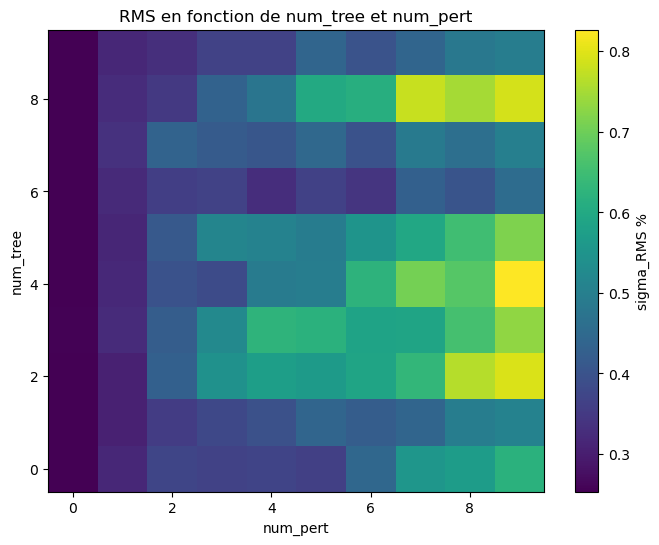

In [14]:
import matplotlib.pyplot as plt
rms_matrix = np.zeros((num_tree, num_pert))

for i in range(num_tree):
    for j in range(num_pert):
        rms_matrix[i, j] = all_tree[i][j]['dataset']['rms']

plt.figure(figsize=(8, 6))

plt.imshow(100*rms_matrix,
           origin='lower',
           aspect='auto',
           cmap='viridis')

plt.colorbar(label='sigma_RMS %')
plt.xlabel('num_pert')
plt.ylabel('num_tree')
plt.title('RMS en fonction de num_tree et num_pert')

plt.show()

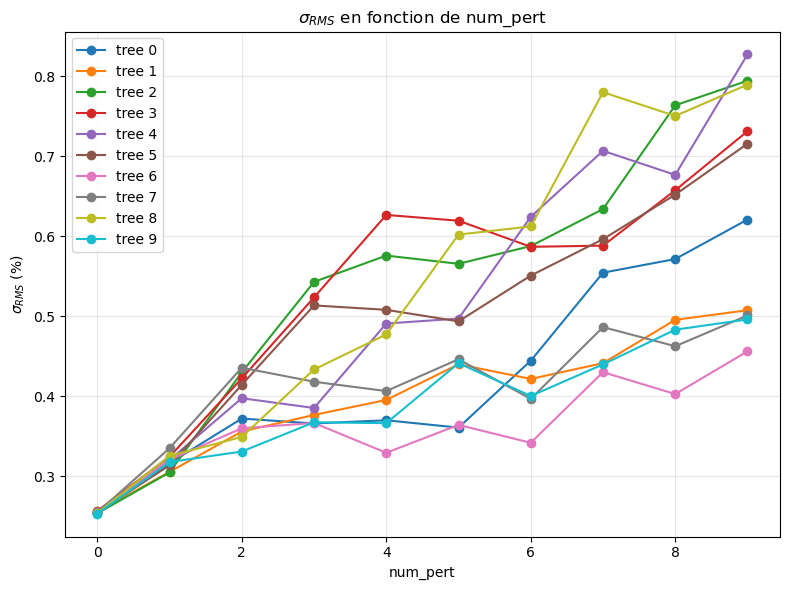

In [16]:
plt.figure(figsize=(8, 6))

x = np.arange(num_pert)

for i in range(num_tree):
    plt.plot(x, 100 * rms_matrix[i, :], marker='o', label=f'tree {i}')

plt.xlabel('num_pert')
plt.ylabel(r'$\sigma_{RMS}$ (%)')
plt.title(r'$\sigma_{RMS}$ en fonction de num_pert')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()